<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
i!pip install kaggle

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("harshadapatil31/student-performance-and-study-habits-dataset")
print(path)

100%|██████████| 14.7k/14.7k [00:00<00:00, 8.59MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/harshadapatil31/student-performance-and-study-habits-dataset/versions/1


In [ ]:
import os

print(os.listdir(path))

['student_performance_dataset.csv']


In [ ]:
import pandas as pd

df = pd.read_csv(path + "/student_performance_dataset.csv")
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [ ]:
df.isnull().sum()

,0
student_id,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,102
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='Density'>

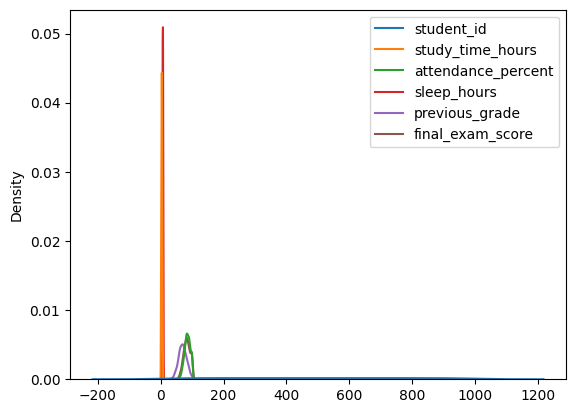

In [ ]:
sns.kdeplot(df)

In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='final_grade', ylabel='count'>

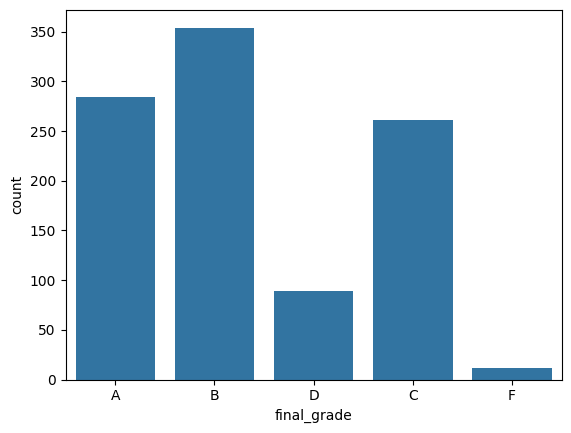

In [ ]:
sns.countplot(data=df, x='final_grade')

<Axes: xlabel='final_exam_score', ylabel='Count'>

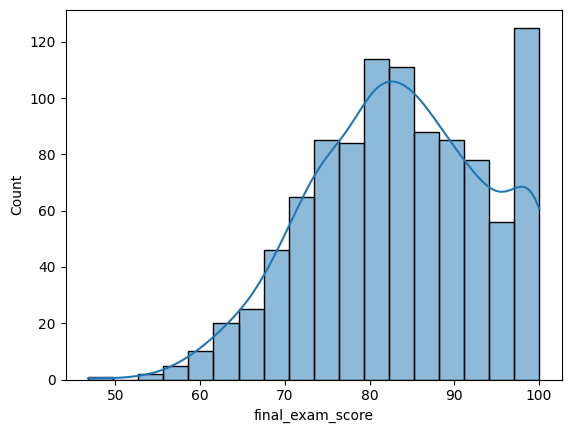

In [ ]:
sns.histplot(df['final_exam_score'], kde=True)



<Axes: xlabel='study_time_hours', ylabel='Count'>

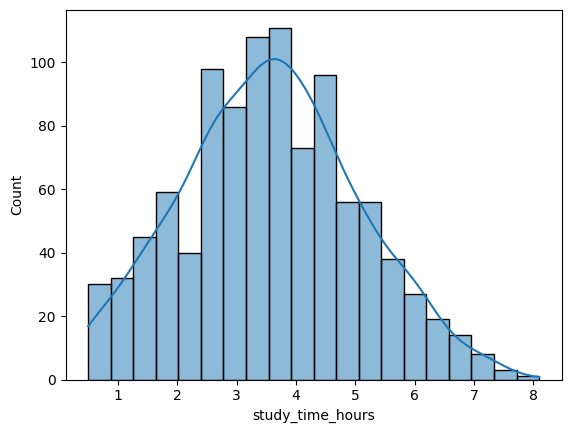

In [ ]:
sns.histplot(df['study_time_hours'], kde=True)


<Axes: xlabel='attendance_percent', ylabel='Count'>

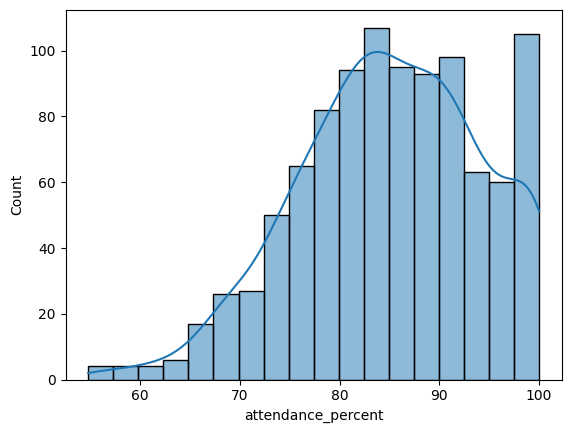

In [ ]:
sns.histplot(df['attendance_percent'], kde=True)


<Axes: xlabel='sleep_hours', ylabel='Count'>

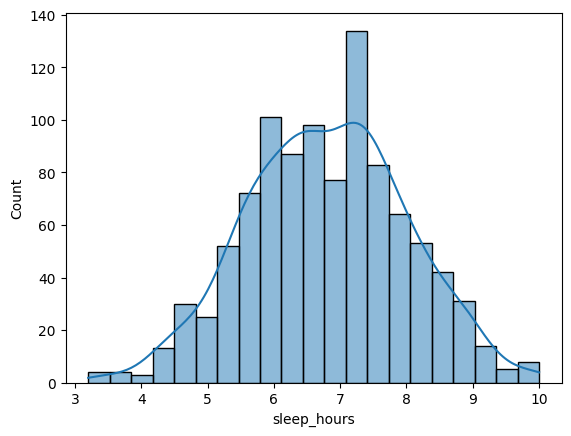

In [ ]:
sns.histplot(df['sleep_hours'], kde=True)


<Axes: xlabel='previous_grade', ylabel='Count'>

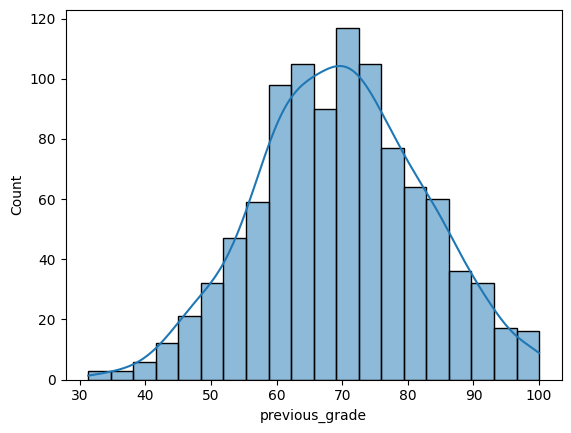

In [ ]:

sns.histplot(df['previous_grade'], kde=True)

array([[<Axes: title={'center': 'student_id'}>,
        <Axes: title={'center': 'study_time_hours'}>],
       [<Axes: title={'center': 'attendance_percent'}>,
        <Axes: title={'center': 'sleep_hours'}>],
       [<Axes: title={'center': 'previous_grade'}>,
        <Axes: title={'center': 'final_exam_score'}>]], dtype=object)

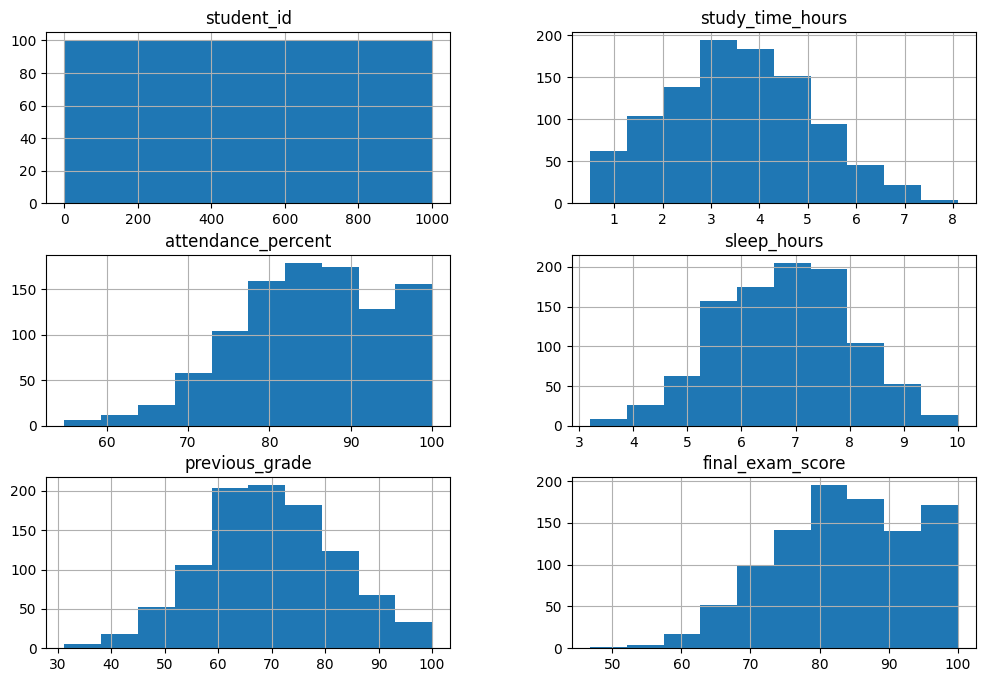

In [ ]:
df.hist(figsize=(12,8))

<Axes: xlabel='study_time_hours', ylabel='Density'>

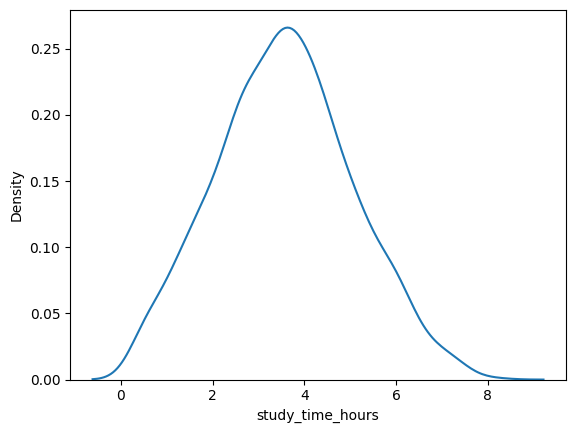

In [ ]:
sns.kdeplot(df['study_time_hours'])

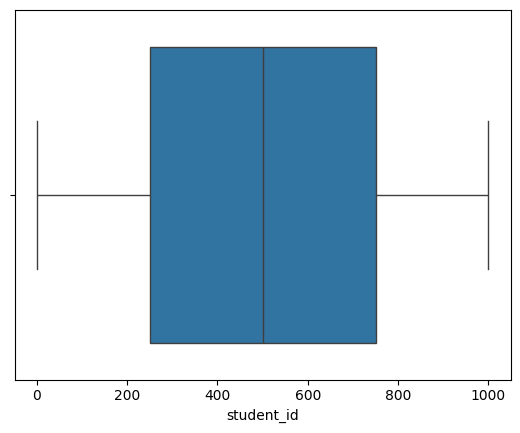

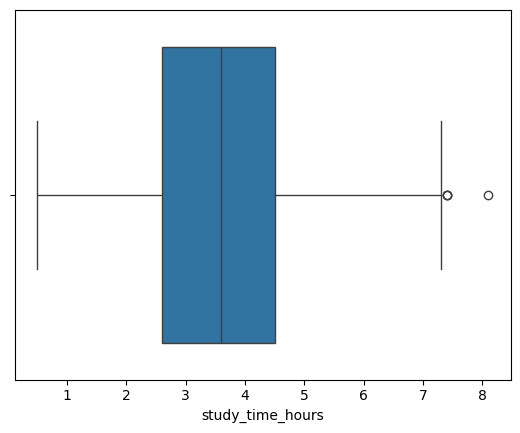

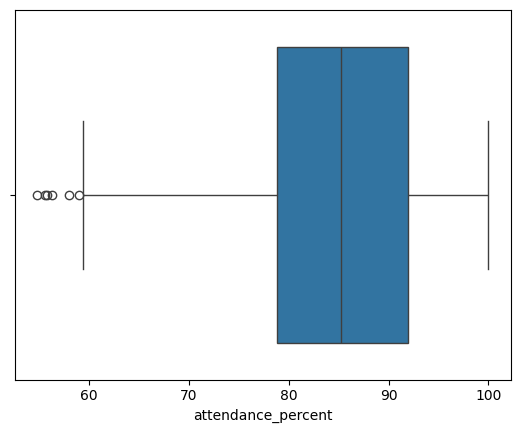

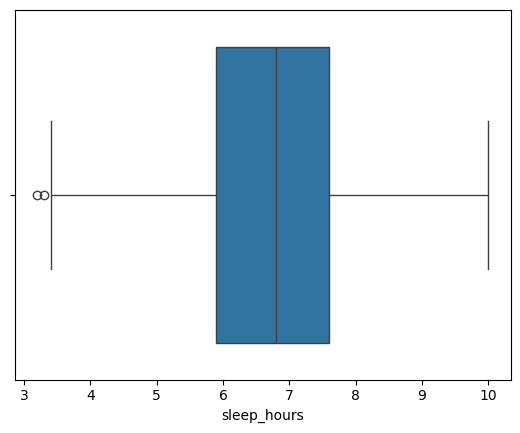

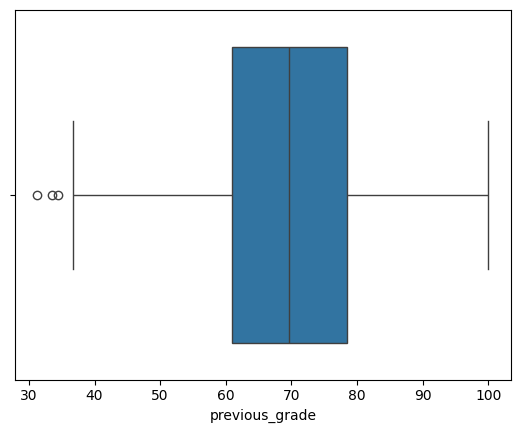

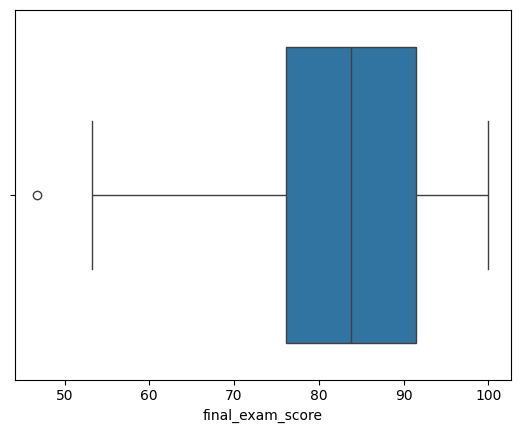

In [ ]:
numerical_columns = df.select_dtypes(include=[np.number]).columns
for col in numerical_columns:
    sns.boxplot(x=df[col])
    plt.show()

<Axes: xlabel='gender', ylabel='count'>

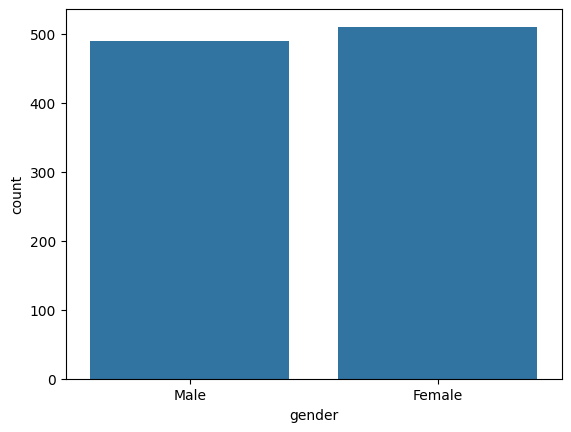

In [ ]:
sns.countplot(data=df,x='gender')

<Axes: >

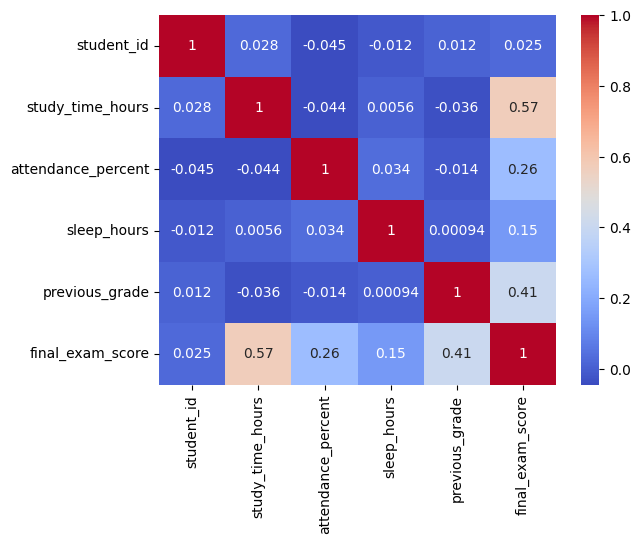

In [ ]:
corr=df.select_dtypes(include='number').corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

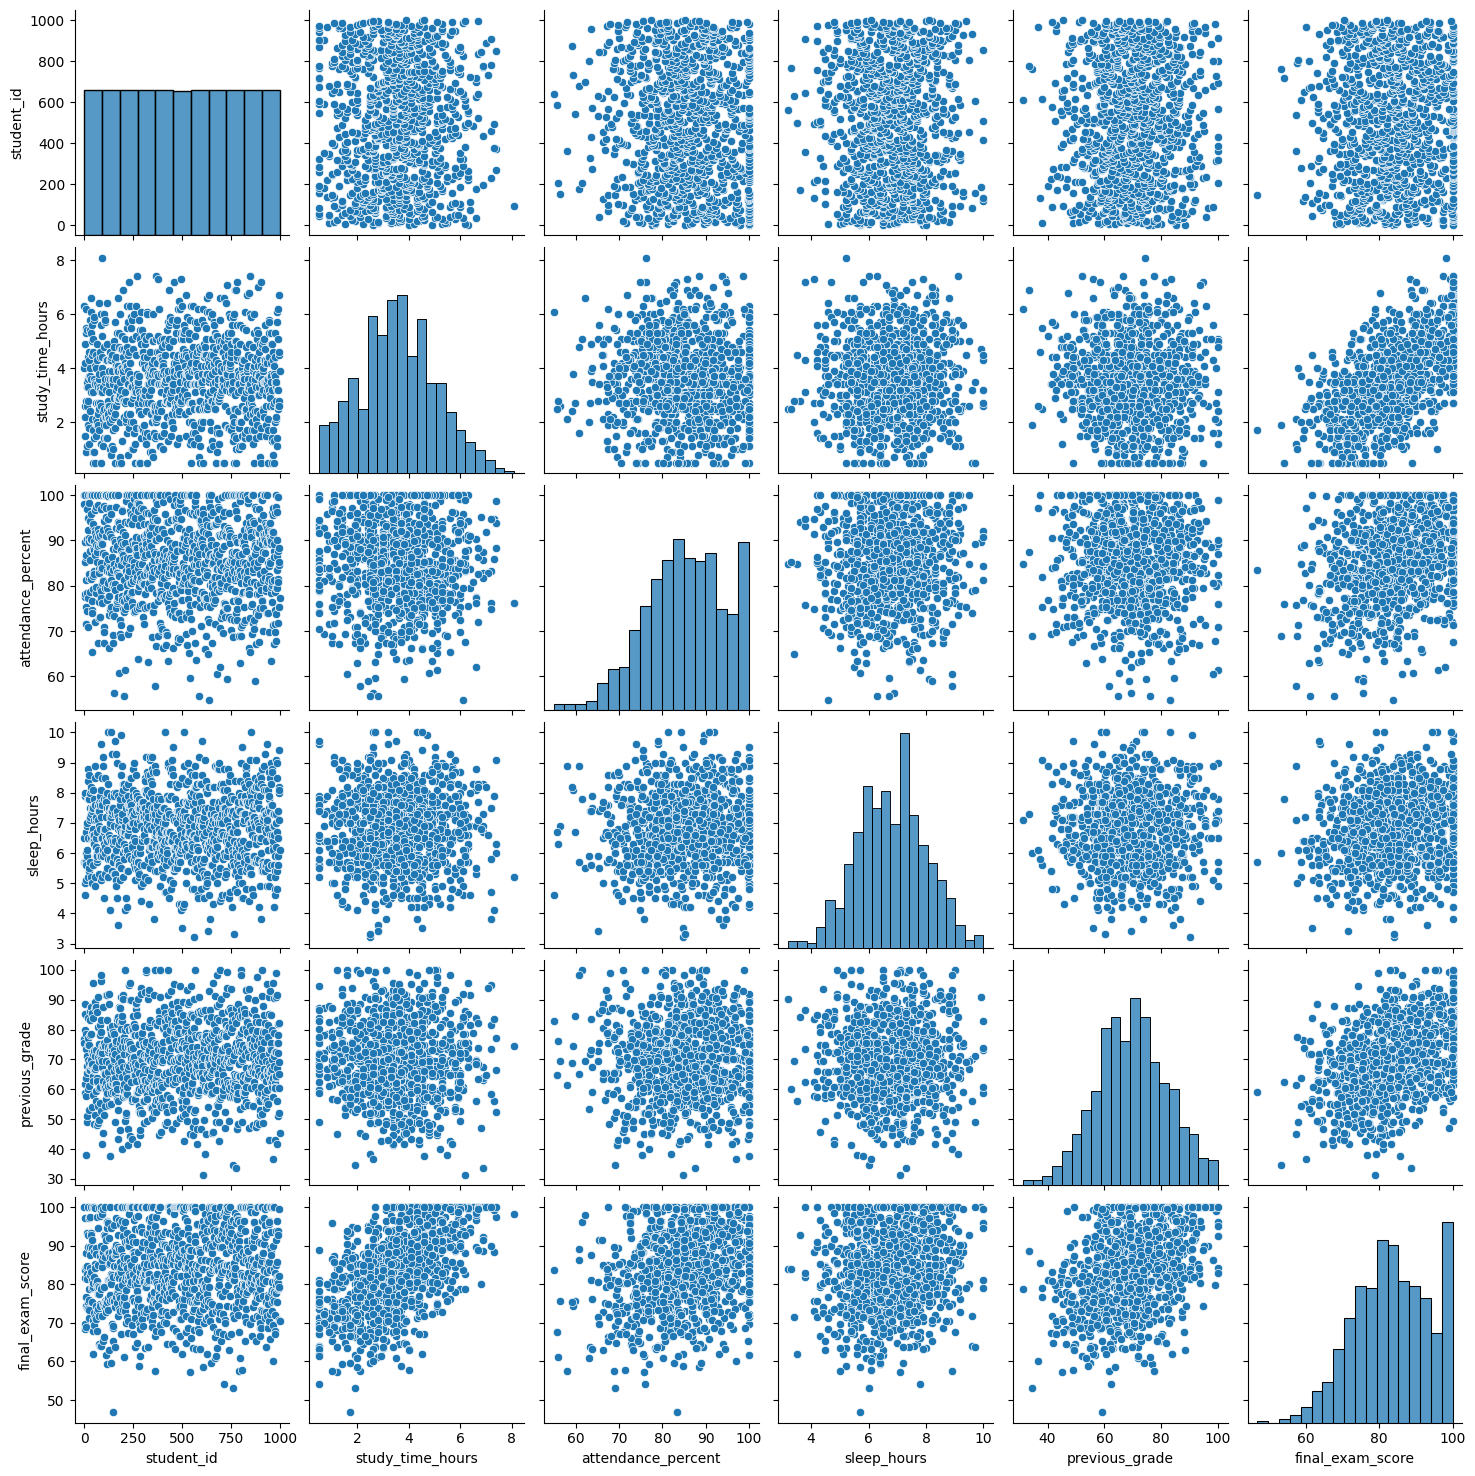

In [ ]:
sns.pairplot(df[numerical_columns])

In [ ]:
df.isnull().sum()

,0
student_id,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,102
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['final_grade','student_id']),
                                               df['final_grade'],
                                               test_size=0.2,
                                               random_state=42)
#

In [ ]:
x_train.sample(5)


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
774,Female,0.5,73.9,6.1,Masters,Yes,Yes,No,75.5,74.6
765,Male,0.5,100.0,6.4,Masters,Yes,Yes,No,65.0,81.1
972,Male,1.3,67.2,7.3,Bachelors,Yes,No,No,79.0,84.1
954,Male,3.7,92.0,7.6,Masters,Yes,Yes,No,65.9,100.0
675,Male,0.5,83.6,6.4,High School,No,Yes,Yes,71.9,61.3


In [ ]:
trf1=ColumnTransformer([
    ('impute_parental',SimpleImputer(strategy='most_frequent'),[4])],
    remainder='passthrough')

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

trf2 = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(),
         [2,3,4,8,9]), # Updated indices for numerical columns

        ('cat', OneHotEncoder(drop='first'),
         [0,1,5,6,7]) # Updated indices for categorical columns


    ],
    remainder='passthrough'
)

In [ ]:
trf3=DecisionTreeClassifier()



In [ ]:
pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3)
])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [ ]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_parental',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [4])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', MinMaxScaler(),
                                                  [2, 3, 4, 8, 9]),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  [0, 1, 5, 6, 7])])),
                ('trf3', DecisionTreeClassifier())])

In [ ]:
y_pred = pipe.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score


accuracy_score(y_test,y_pred)


0.995

In [ ]:
# cross validation using cross_val_score
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, x_train, y_train, cv=5, scoring='accuracy').mean()

np.float64(0.9974999999999999)

In [ ]:
# export
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))

In [ ]:
from google.colab import files

files.download('pipe.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
x_train

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
29,Female,2.4,94.3,7.1,Bachelors,Yes,Yes,No,86.8,89.8
535,Female,2.0,92.5,7.7,High School,Yes,No,No,58.7,77.6
695,Female,3.0,91.0,7.0,High School,Yes,Yes,No,56.6,77.5
557,Female,3.4,81.6,6.6,High School,Yes,Yes,No,47.4,73.1
836,Male,4.5,92.4,8.4,Bachelors,Yes,Yes,Yes,90.7,100.0
...,...,...,...,...,...,...,...,...,...,...
106,Female,3.6,79.4,6.2,High School,Yes,Yes,Yes,74.6,75.7
270,Female,3.5,86.7,5.5,Masters,Yes,Yes,No,58.6,75.1
860,Female,3.6,76.0,7.3,High School,Yes,No,No,85.4,91.1
435,Female,5.6,85.8,7.8,High School,Yes,Yes,Yes,76.4,93.4


In [ ]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [ ]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git add ML_Pipeline.ipynb

fatal: pathspec 'ML_Pipeline.ipynb' did not match any files
